# Calibración de modelos
**Aprendizaje de Máquina - CEIA - FIUBA**

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.calibration import (
    CalibratedClassifierCV,
    CalibrationDisplay,
    calibration_curve,
)
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## ¿Por qué es importante calibrar modelos?

A continuación vamos a entrenar un modelo **GaussianNB** con un dataset real: [**Breast Cancer Wisconsin**](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) y vamos a analizar sus probabilidades.

Para eso vamos a usar el [módulo de calibración de ScikitLearn](https://scikit-learn.org/stable/modules/calibration.html).

In [2]:
# Cargamos los datos
data = load_breast_cancer()
X = data.data
y = data.target

print(f"Dataset: {X.shape[0]} muestras, {X.shape[1]} features")
print(f"Clase positiva (benigno): {y.mean():.2%}\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)


Dataset: 569 muestras, 30 features
Clase positiva (benigno): 62.74%



Armemos el modelo...

In [3]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)

pred_gnb = gnb.predict(X_test)
probs_gnb = gnb.predict_proba(X_test)[:,1]

# Métricas
acc_gnb = accuracy_score(y_test, pred_gnb)

print(f"Accuracy: {acc_gnb:.3f}")

Accuracy: 0.947


Calculemos métricas de calibración para el modelo de Naive Bayes.

Brier Score:  0.049


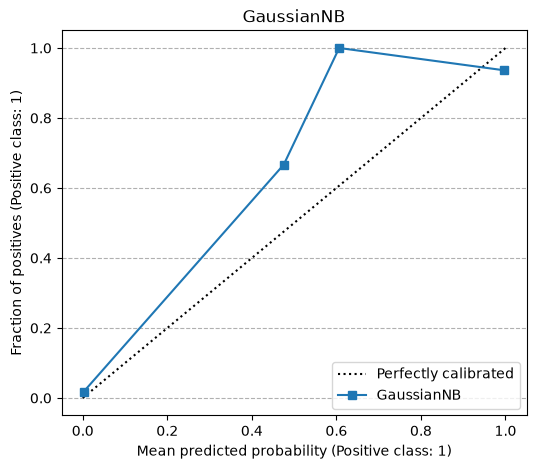

In [4]:
brier_gnb = brier_score_loss(y_test, probs_gnb)

print(f"Brier Score:  {brier_gnb:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_estimator(gnb, X_test, y_test, ax=ax)
ax.grid(axis='y', ls='--')
plt.title("GaussianNB")
plt.show()


GaussianNB muestra un comportamiento típico de modelos mal calibrados:

- Predice probabilidades muy extremas (cercanas a 0 o 1)
- Su curva sin calibrar queda lejos de la diagonal ideal.


## 1. Datos sintéticos

Vamos a comparar los resultados de modelos sin calibrar vs modelos calibrados, usando datos sintéticos.

In [5]:
X_s, y_s = make_classification(n_samples=10000, n_features=20, n_informative=15,
                                   n_redundant=5, random_state=42, flip_y=0.02)

print(f"Dataset: {X_s.shape[0]} muestras, {X_s.shape[1]} features")
print(f"Clase positiva: {y_s.mean():.2%}\n")

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_s, y_s, test_size=0.3, random_state=42, stratify=y_s)


Dataset: 10000 muestras, 20 features
Clase positiva: 49.97%



Empezamos entrenando con logistic regression.

In [6]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train_s)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Ahora entrenamos un random forest.

In [7]:
# 2. Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train_s, y_train_s)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Ahora entrenamos un random forest con calibración Platt scaling (sigmoid).

In [8]:
# 3. Random Forest + calibración Platt Scaling (sigmoid)
rf_platt = CalibratedClassifierCV(rf, method='sigmoid', cv=5)
rf_platt.fit(X_train_s, y_train_s)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...t 0x119fc20f0>, <sk

Repetimos, ahora con calibración Isotonic.

In [9]:
# 4. Random Forest + calibración Isotonic
rf_iso = CalibratedClassifierCV(rf, method='isotonic', cv=5)
rf_iso.fit(X_train_s, y_train_s)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...t 0x11a1b7530>, <s

Obtengamos ahora las métricas de calibración para los modelos, obteniendo primero las predicciones de probabilidad.

In [10]:
probs_rf = rf.predict_proba(X_test_s)[:, 1]
probs_platt = rf_platt.predict_proba(X_test_s)[:, 1]
probs_iso = rf_iso.predict_proba(X_test_s)[:, 1]

#### Probabilidad original vs calibrada

Grafiquemos las predicciones originales vs las calibradas:

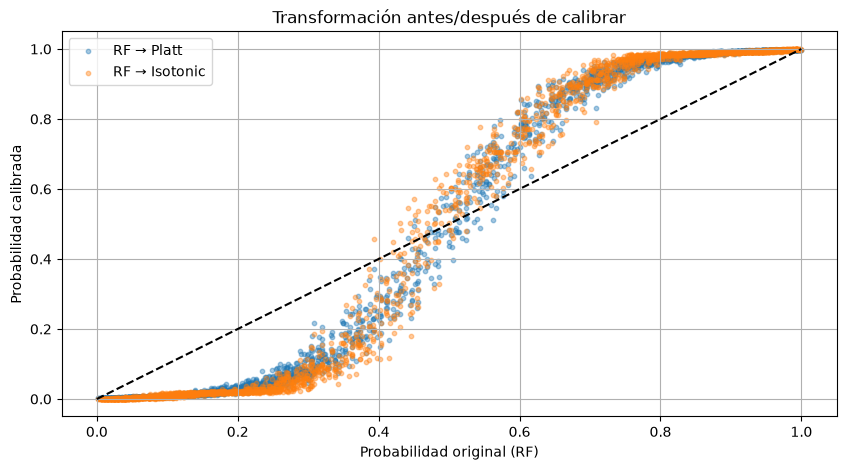

In [11]:
plt.figure(figsize=(10, 5))

plt.scatter(probs_rf, probs_platt, s=10, alpha=0.4, label="RF → Platt")
plt.scatter(probs_rf, probs_iso, s=10, alpha=0.4, label="RF → Isotonic")

plt.plot([0,1],[0,1],'k--') 
plt.xlabel("Probabilidad original (RF)")
plt.ylabel("Probabilidad calibrada")
plt.title("Transformación antes/después de calibrar")
plt.legend()
plt.grid(True)
plt.show()


Este gráfico nos muestra exactamente cómo la calibración transforma las probabilidades. Cada punto es una predicción. En el eje X tenemos la probabilidad original y en el eje Y la probabilidad calibrada.

#### Curvas de calibración (o Reliability Diagrams)

Las curvas de calibración comparan la confianza predicha vs la frecuencia real.
Si la línea está cerca o sobre la diagonal, las probabilidades son buenas, la calibración es perfecta.

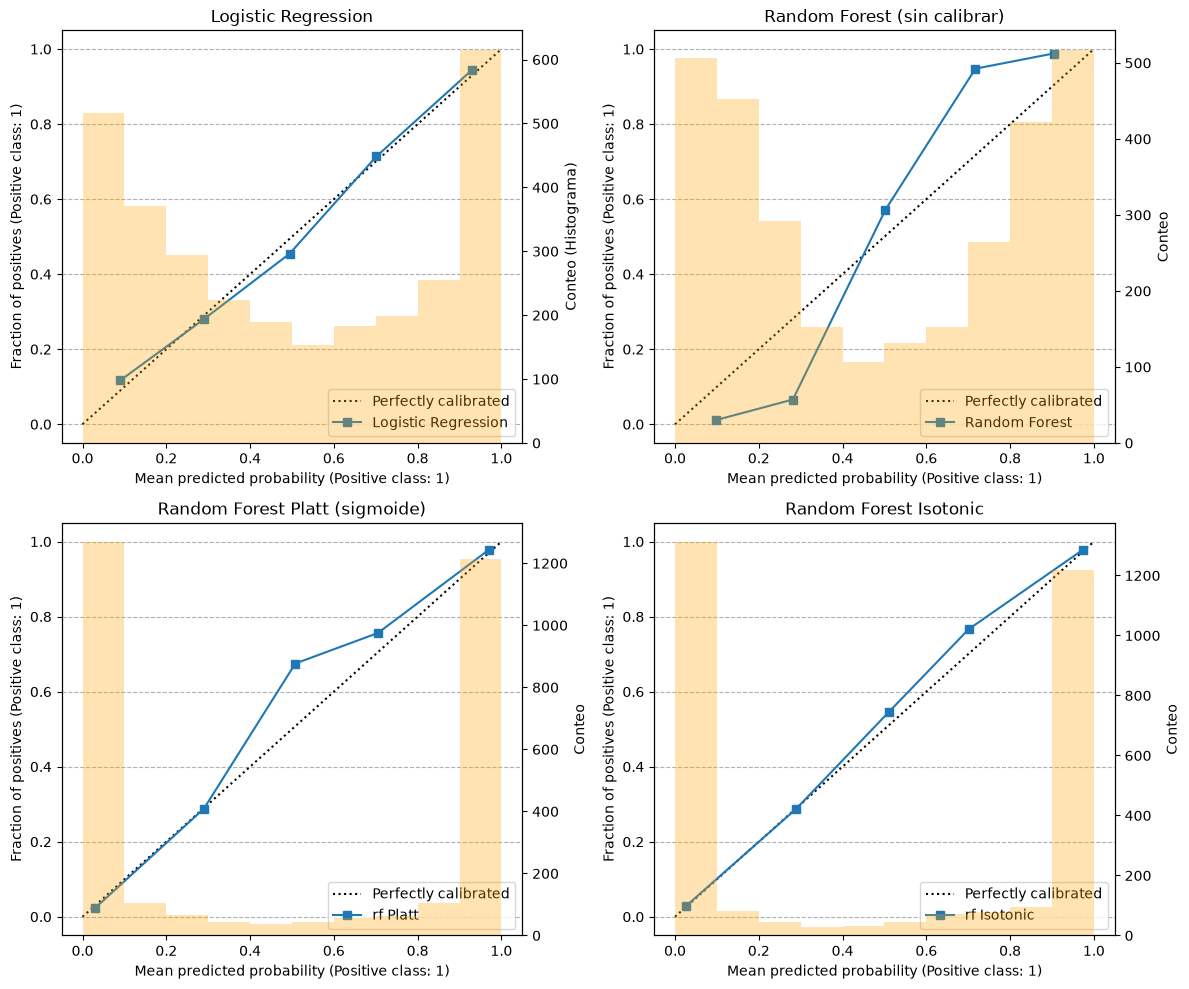

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Configuración común del histograma ---
hist_params = {'bins': 10, 'range': (0, 1), 'alpha': 0.3, 'color': 'orange', 
    'edgecolor': 'none'}

# 1. Logistic Regression
ax1 = axes[0, 0]
CalibrationDisplay.from_estimator(lr, X_test_s, y_test_s, name='Logistic Regression',
    ax=ax1)
# Calculamos probabilidades para el histograma
prob_lr = lr.predict_proba(X_test_s)[:, 1]
# Creamos eje gemelo
ax1_hist = ax1.twinx()
ax1_hist.hist(prob_lr, **hist_params)
ax1_hist.set_ylabel("Conteo (Histograma)") # Opcional
ax1.set_title("Logistic Regression")
ax1.grid(axis="y", ls='--')


# 2. Random Forest (Sin calibrar)
ax2 = axes[0, 1]
CalibrationDisplay.from_estimator(rf, X_test_s, y_test_s, name='Random Forest', ax=ax2)
prob_rf = rf.predict_proba(X_test_s)[:, 1]
ax2_hist = ax2.twinx()
ax2_hist.hist(prob_rf, **hist_params)
ax2_hist.set_ylabel("Conteo")
ax2.set_title("Random Forest (sin calibrar)")
ax2.grid(axis="y", ls='--')


# 3. Random Forest Platt
ax3 = axes[1, 0]
CalibrationDisplay.from_estimator(rf_platt, X_test_s, y_test_s, name='rf Platt', ax=ax3)
prob_platt = rf_platt.predict_proba(X_test_s)[:, 1]
ax3_hist = ax3.twinx()
ax3_hist.hist(prob_platt, **hist_params)
ax3_hist.set_ylabel("Conteo")
ax3.set_title("Random Forest Platt (sigmoide)")
ax3.grid(axis="y", ls='--')


# 4. Random Forest Isotonic
ax4 = axes[1, 1]
CalibrationDisplay.from_estimator(rf_iso, X_test_s, y_test_s, name='rf Isotonic',
    ax=ax4)
prob_iso = rf_iso.predict_proba(X_test_s)[:, 1]
ax4_hist = ax4.twinx()
ax4_hist.hist(prob_iso, **hist_params)
ax4_hist.set_ylabel("Conteo")
ax4.set_title("Random Forest Isotonic")
ax4.grid(axis="y", ls='--')

plt.tight_layout()
plt.show()

#### ¿Qué revelan estas curvas?

- Logistic regression suele estar bien calibrada (queda casi pegada a la diagonal).
- Random Forest (sin calibrar) es muy confiado (la curva está aplastada en 0 y 1).
- Random Forest + Platt mejora mucho (queda cerca de la línea perfecta).
- Random Forest + Isotonic mejora muchísimo (queda muy cerca de la línea perfecta).

#### Métricas

El `Brier Score` mide qué tan lejos están las probabilidades de la realidad. Mientras más bajo, mejor.

In [13]:
def resumen_calibracion(y, probs):
    return {
        "Brier": brier_score_loss(y, probs),
        "LogLoss": log_loss(y, probs),
        "Accuracy": accuracy_score(y, (probs >= 0.5))  # noqa: PLR2004
    }

modelos = {
    "Logistic Regression": lr.predict_proba(X_test_s)[:,1],
    "RF (sin calibrar)": rf.predict_proba(X_test_s)[:,1],
    "Platt": rf_platt.predict_proba(X_test_s)[:,1],
    "Isotonic": rf_iso.predict_proba(X_test_s)[:,1],
}

print(pd.DataFrame({k: resumen_calibracion(y_test_s, v) for k,v in modelos.items()}).T)


                        Brier   LogLoss  Accuracy
Logistic Regression  0.132040  0.414975  0.818333
RF (sin calibrar)    0.061483  0.243888  0.952333
Platt                0.040546  0.153393  0.948000
Isotonic             0.040537  0.183336  0.950667


**Pero por qué la regresión logística tiene peor Brier Score que el Random Forest?**

La regresión logística presentó en la curva de calibración que se ajusta casi perfectamente a la curva ideal, lo que indica que el modelo está calibrado correctamente. Pero el Brier Score, tal como lo calculamos no solo mide la calibración, sino la discriminación. Por ejemplo, si tenemos un caso Positivo (1):

- La regresión logística predice una probabilidad de 0.55, el error es de $(1 - 0.55)^2 \approx 0.2$
- El Random Forest predice una probabilidad de 0.9, el error es de $(1 - 0.9)^2 \approx 0.01$

Dada la descomposición del Brier Score, el Random Forest tiene un error menor que la regresión logística, lo que indica que el Random Forest tiene mejor discriminación que la regresión logística, haciendo que esta métrica sea más baja. Por lo que cuando usamos el Brier Score, no solo evaluamos calibración, sino también discriminación. 

---
## 2. Dataset real: Breast Cancer Wisconsin

Repetimos el experimento de calibración con el modelo Naive-Bayes y el dataset Breast Cancer Wisconsin.

In [14]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Entrenamos un Bayesiano
gnb = make_pipeline(
    StandardScaler(),
    GaussianNB() 
)

gnb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('gaussiannb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


Ahora armamos la versión calibrada:

In [15]:
gnb_iso = make_pipeline(
    StandardScaler(),
    CalibratedClassifierCV(
        estimator=GaussianNB(),
        method='isotonic', cv=5
    )
)
gnb_iso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('calibratedclassifiercv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


Veamos los resultados:

In [16]:
probs_gnb = gnb.predict_proba(X_test)[:, 1]
probs_iso = gnb_iso.predict_proba(X_test)[:, 1]

#### Histogramas

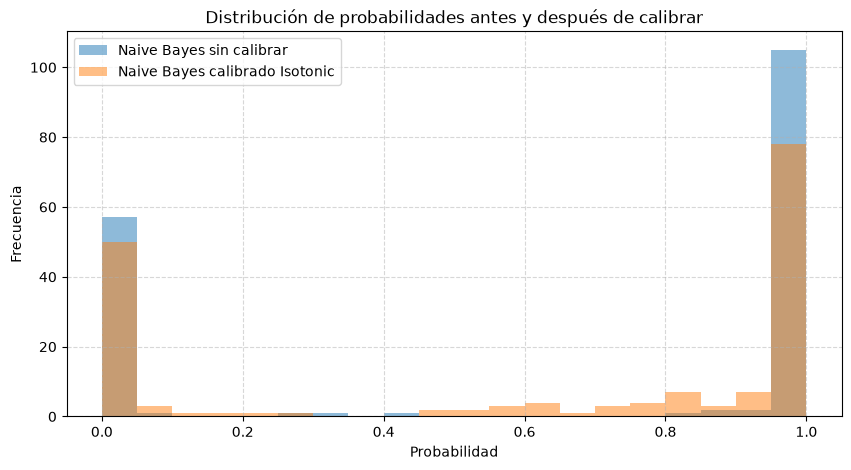

In [17]:
plt.figure(figsize=(10, 5))

# modelo sin calibrar
plt.hist(probs_gnb, bins=20, alpha=0.5, label="Naive Bayes sin calibrar")

# modelo calibrado con Isotonic
plt.hist(probs_iso, bins=20, alpha=0.5, label="Naive Bayes calibrado Isotonic")

plt.xlabel("Probabilidad")
plt.ylabel("Frecuencia")
plt.title("Distribución de probabilidades antes y después de calibrar")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


### Función para graficar la curva de calibración

Armemos una función para graficar la curva de calibración.

In [18]:
def plot_calibration(y_true, probs_dict, title="Curva de calibración", size=(9,6)):
    plt.figure(figsize=size)
    plt.plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado")

    colors = plt.cm.Dark2.colors 
    
    for i, (name, prob) in enumerate(probs_dict.items()):
        color = colors[i % len(colors)]
        
        frac_pos, mean_pred = calibration_curve(
            y_true, prob, n_bins=5
        )
        brier = brier_score_loss(y_true, prob)
        acc = accuracy_score(y_true, (prob >= 0.5).astype(int))  # noqa: PLR2004

        plt.plot(mean_pred, frac_pos, marker="o", color=color, linewidth=2,
                 label=f"{name}\nBrier={brier:.3f} | Acc={acc:.3f}")

    plt.xlabel("Probabilidad predicha media")
    plt.ylabel("Fracción de positivos reales")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


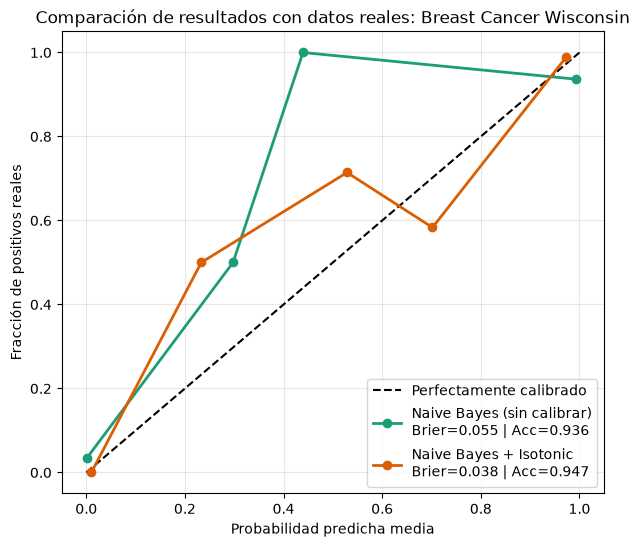

In [19]:
probs = {
    "Naive Bayes (sin calibrar)": gnb.predict_proba(X_test)[:, 1],
    "Naive Bayes + Isotonic": gnb_iso.predict_proba(X_test)[:, 1]
}

plot_calibration(y_test, probs, "Comparación de resultados con datos reales: " 
    "Breast Cancer Wisconsin", size=(7,6))

#### Métricas

In [20]:
def resumen_calibracion(y, probs):
    return {
        "Brier": brier_score_loss(y, probs),
        "LogLoss": log_loss(y, probs),
        "Accuracy": (probs >= 0.5).mean()  # noqa: PLR2004
    }

modelos = {
    "NB (sin calibrar)": gnb.predict_proba(X_test)[:,1],
    "Isotonic": gnb_iso.predict_proba(X_test)[:,1],
}

print(pd.DataFrame({k: resumen_calibracion(y_test, v) for k,v in modelos.items()}).T)


                      Brier   LogLoss  Accuracy
NB (sin calibrar)  0.055406  0.363561  0.643275
Isotonic           0.038081  0.117748  0.654971
